In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Access the csv data file
df = pd.read_csv('https://github.com/bipulshahi/Dataset/raw/refs/heads/main/Country-data.xls')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
#Drop the country column as it is non-numeric
df1 = df.drop(columns = ['country'])
df1.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
#Perform data scaling - for better result interpretation
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df2 = scaler.fit_transform(df1)

In [ ]:
#Elbow method to decide number of clusters
from sklearn.cluster import KMeans

inertia = []

for k in range(1,13):
  modelA = KMeans(n_clusters=k)
  modelA.fit(df2)
  inertia.append(modelA.inertia_)

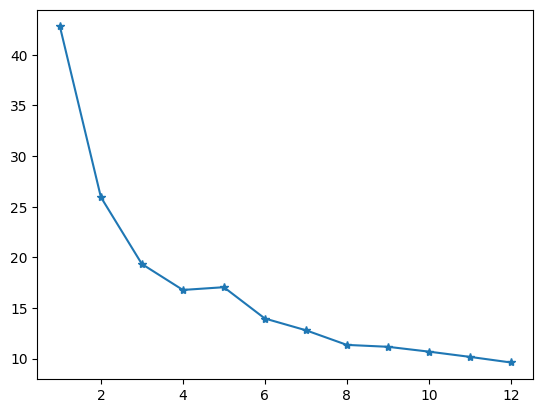

In [ ]:
#Plot inertai value to check elbow position
plt.plot(range(1,13) , inertia , marker = '*')
plt.show()

In [ ]:
#Fit the data to get trained
modelB = KMeans(n_clusters=4)
modelB.fit(df2)

KMeans(n_clusters=4)

In [ ]:
#Centeroid or ceneteroid of each cluster
print(modelB.cluster_centers_)

[[0.02111733 0.56545067 0.20222188 0.50433814 0.57412514 0.09847057
  0.93491124 0.09818612 0.4756321 ]
 [0.09645883 0.2043646  0.27611924 0.2739664  0.09696778 0.10923141
  0.79639076 0.18307408 0.06008786]
 [0.00946662 0.20302861 0.51062312 0.22669733 0.30017564 0.05132441
  0.95273577 0.09428672 0.39372793]
 [0.44855566 0.14374556 0.27839238 0.24371101 0.0236866  0.15178408
  0.53732194 0.62446547 0.01406841]]


In [ ]:
#Centeroid or ceneteroid of each cluster
df_cc = pd.DataFrame(modelB.cluster_centers_, columns = df1.columns)
df_cc

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,0.021117,0.565451,0.202222,0.504338,0.574125,0.098471,0.934911,0.098186,0.475632
1,0.096459,0.204365,0.276119,0.273966,0.096968,0.109231,0.796391,0.183074,0.060088
2,0.009467,0.203029,0.510623,0.226697,0.300176,0.051324,0.952736,0.094287,0.393728
3,0.448556,0.143746,0.278392,0.243711,0.023687,0.151784,0.537322,0.624465,0.014068


<Axes: >

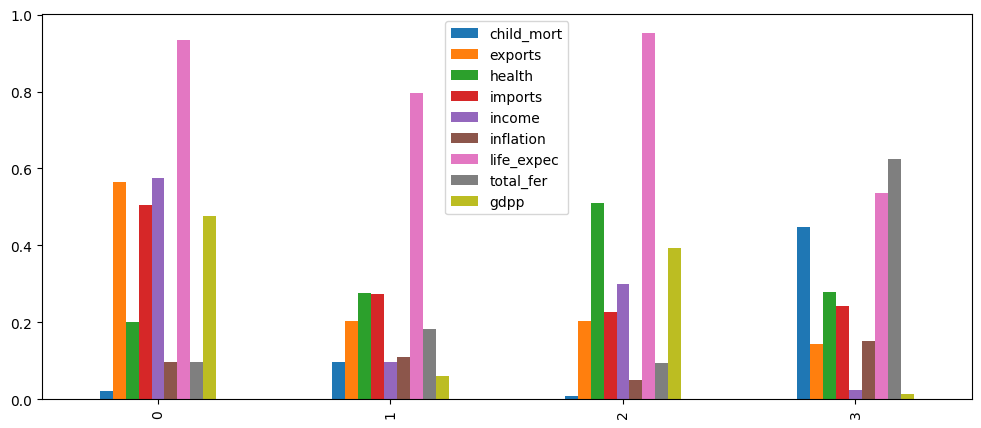

In [ ]:
#Plotting ceteroid value of each cluster to understand its significance
df_cc.plot.bar(figsize = (12,5))

**After clustering and analysing cluster centers - group/cluster 3 is showing values where NGP can extend their help**

In [ ]:
#Predicting ouput of each sample and storing them into a new 'Label' Column
df['Label'] = modelB.predict(df2)

In [ ]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Label
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,3
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,1
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,3
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,1


In [ ]:
#Filter countries from cluster 3
df[df['Label'] == 3]['country']

,country
0,Afghanistan
3,Angola
17,Benin
25,Burkina Faso
26,Burundi
28,Cameroon
31,Central African Republic
32,Chad
36,Comoros
37,"Congo, Dem. Rep."


**silhouette score**

In [ ]:
df = pd.read_csv('https://github.com/bipulshahi/Dataset/raw/refs/heads/main/Country-data.xls')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
df1 = df.drop(columns = ['country'])
df1.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import MinMaxScaler

In [ ]:
minmaxscler = MinMaxScaler()
df2 = minmaxscler.fit_transform(df1)

In [ ]:
silhouette_scores = []

for k in range(2,10):
  modelC = KMeans(n_clusters=k)
  modelC.fit(df2)
  labels = modelC.predict(df2)                          #predicting the cluster label for each data sample
  score = silhouette_score(df2, labels)
  silhouette_scores.append(score)
  print(f"k={k} , Silhoutte score = {score}")

k=2 , Silhoutte score = 0.37671430588173554
k=3 , Silhoutte score = 0.34265474105126204
k=4 , Silhoutte score = 0.29749728260272906
k=5 , Silhoutte score = 0.2592439260657805
k=6 , Silhoutte score = 0.19891687359165303
k=7 , Silhoutte score = 0.20631983778315352
k=8 , Silhoutte score = 0.2233351081567181
k=9 , Silhoutte score = 0.21293274647159693


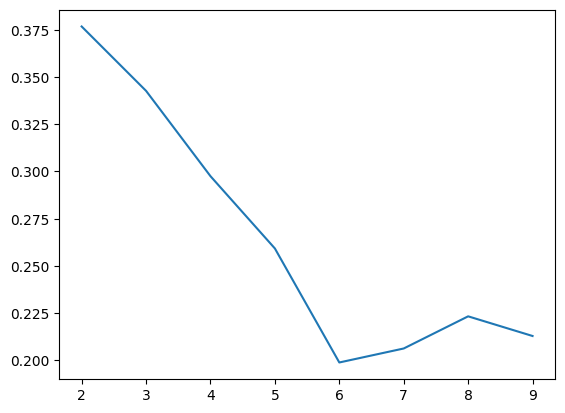

In [ ]:
plt.plot(range(2,10) , silhouette_scores)
plt.show()

In [ ]:
k_range = np.arange(2,10)
print(k_range)

[2 3 4 5 6 7 8 9]


In [ ]:
k_range[np.argmax(silhouette_scores)]

np.int64(2)